**Import Libraries**

In [31]:
import pandas as pd # Import the pandas library for data manipulation and analysis
import numpy as np # Import the numpy library for numerical operations, especially with arrays

import matplotlib.pyplot as plt # Import matplotlib.pyplot for creating static, interactive, and animated visualizations
import seaborn as sns # Import seaborn for statistical data visualization, built on matplotlib

from sklearn.model_selection import train_test_split # Import train_test_split for splitting data into training and testing sets

from sklearn.linear_model import LinearRegression # Import LinearRegression for building a linear regression model

from sklearn.metrics import ( # Import various metrics for evaluating regression models
    mean_absolute_error, # Mean Absolute Error
    mean_squared_error, # Mean Squared Error
    r2_score # R-squared score
)

import warnings # Import the warnings module to manage warnings
warnings.filterwarnings("ignore") # Ignore all warning messages during execution

**Load Dataset**

In [32]:
df = pd.read_csv("student-mat.csv", sep=";") # Load the dataset from 'student-mat.csv' into a pandas DataFrame, using semicolon as a separator

In [33]:
df # Display the entire DataFrame to view its contents

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
390,MS,M,20,U,LE3,A,2,2,services,services,...,5,5,4,4,5,4,11,9,9,9
391,MS,M,17,U,LE3,T,3,1,services,services,...,2,4,5,3,4,2,3,14,16,16
392,MS,M,21,R,GT3,T,1,1,other,other,...,5,5,3,3,3,3,3,10,8,7
393,MS,M,18,R,LE3,T,3,2,services,other,...,4,4,1,3,4,5,0,11,12,10


**Explore Dataset**

In [34]:
df.head() # Display the first 5 rows of the DataFrame to get a quick overview of the data

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [35]:
df.shape # Display the number of rows and columns (shape) of the DataFrame

(395, 33)

In [36]:
df.columns # Display the names of all columns in the DataFrame

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='object')

In [37]:
df.info() # Display a summary of the DataFrame, including data types, non-null values, and memory usage

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

In [38]:
df.describe() # Display descriptive statistics for numerical columns, such as count, mean, std, min, max, and quartiles

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


**Missing Values**

In [39]:
df.isnull().sum() # Calculate and display the count of missing (null) values for each column in the DataFrame

,0
school,0
sex,0
age,0
address,0
famsize,0
Pstatus,0
Medu,0
Fedu,0
Mjob,0
Fjob,0


**Correlation**

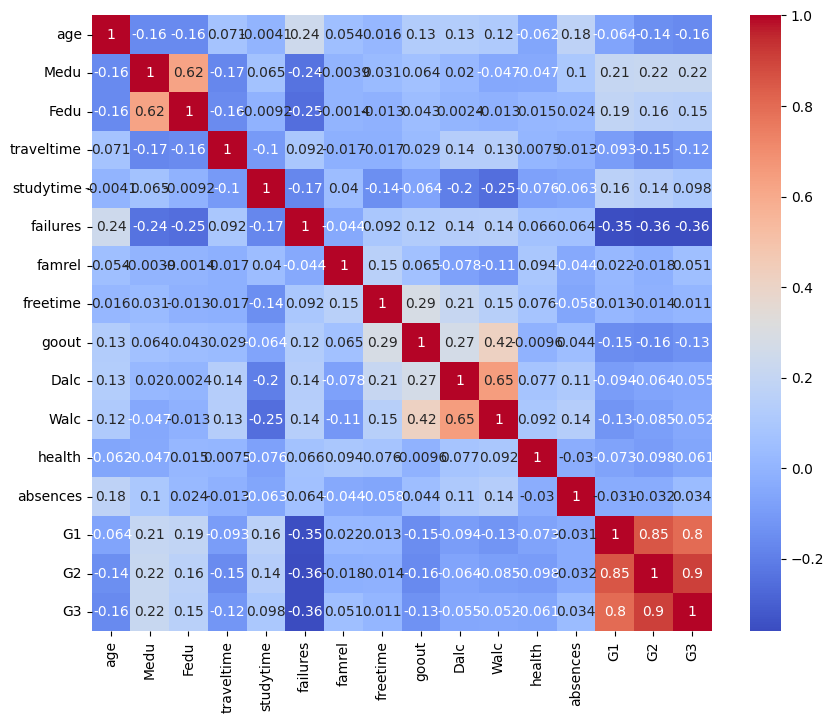

In [40]:
plt.figure(figsize=(10,8)) # Create a new figure for the plot with a specified size (width=10, height=8 inches)

sns.heatmap( # Generate a heatmap plot
    df.corr(numeric_only=True), # Calculate the correlation matrix for only numerical columns in the DataFrame
    annot=True, # Annotate each cell with the correlation coefficient value
    cmap="coolwarm" # Set the color map for the heatmap to 'coolwarm'
)

plt.show() # Display the generated heatmap

**Scatter Plots**

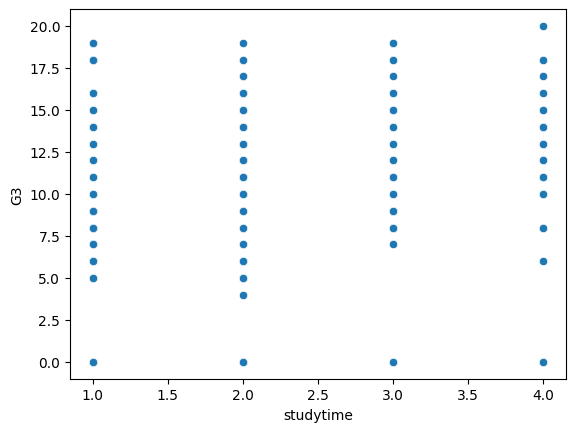

In [41]:
sns.scatterplot( # Create a scatter plot
    x="studytime", # Set 'studytime' column as the x-axis variable
    y="G3", # Set 'G3' (final grade) column as the y-axis variable
    data=df # Specify the DataFrame to use for plotting
)

plt.show() # Display the generated scatter plot

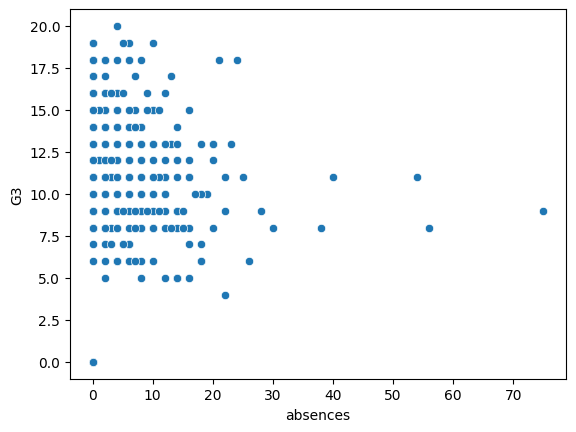

In [42]:
# Absence vs Final Grade

sns.scatterplot( # Create a scatter plot
    x="absences", # Set 'absences' column as the x-axis variable
    y="G3", # Set 'G3' (final grade) column as the y-axis variable
    data=df # Specify the DataFrame to use for plotting
)

plt.show() # Display the generated scatter plot

**Select Features**

In [43]:
X = df[[ # Select specific columns to be used as features (independent variables)
    "studytime", # Study time
    "failures", # Number of past failures
    "absences", # Number of school absences
    "G1", # First period grade
    "G2" # Second period grade
]]

In [44]:
#TARGET

y = df["G3"] # Select the 'G3' column as the target variable (dependent variable, final grade)

**Train-Test Split**

In [45]:
X_train, X_test, y_train, y_test = train_test_split( # Split the data into training and testing sets
    X, # Features DataFrame
    y, # Target Series
    test_size=0.20, # Allocate 20% of the data for testing
    random_state=42 # Set a random state for reproducibility of the split
)

**Create Model**

In [46]:
model = LinearRegression() # Instantiate a Linear Regression model

**Train Model**

In [47]:
model.fit( # Train the Linear Regression model
    X_train, # Training features
    y_train # Training target variable
)

LinearRegression()

**Coefficients**

In [48]:
coefficients = pd.DataFrame({ # Create a DataFrame to display the model's coefficients
    "Feature": X.columns, # Column names as features
    "Coefficient": model.coef_ # Corresponding coefficients from the trained model
})

coefficients # Display the coefficients DataFrame

,Feature,Coefficient
0,studytime,-0.071231
1,failures,-0.455813
2,absences,0.039245
3,G1,0.144463
4,G2,0.979615


**Intercept**

In [49]:
print(model.intercept_) # Print the intercept (bias) of the linear regression model

-1.6213124035190898


**Prediction**

In [50]:
y_pred = model.predict(X_test) # Make predictions on the test set using the trained model
y_pred

array([ 6.01113762, 12.20306263,  3.42583945,  8.52243043,  7.87300271,
       12.70478596, 18.6925959 ,  7.10011213,  7.22885591, 12.6388124 ,
       14.95294333,  6.26901605, 13.65241561, 11.65193785, 14.43175056,
        7.74073579,  6.24924059, 10.67958176, 15.17063948,  8.35493681,
       14.20153818, 16.12152392, 14.95294333,  5.07170458,  7.92154672,
       19.91293763, 10.45863081,  9.18808655, 17.12987012, 10.77259   ,
        9.31519509,  7.23611513, 15.02617612, 12.86176556,  6.03354665,
        4.1659295 , -2.02631531, 15.10992293, 11.87489101,  7.6285779 ,
        4.43648929, 10.16770188, 14.05907703,  7.82649858, 15.53605378,
        9.62147664, 12.05164607, 14.44687646, 12.50886749, 15.61454358,
       13.37890245, 14.95294333, 10.31216524,  8.36545083,  4.34702809,
       12.95802861,  9.8444298 ,  5.96031387, 15.17589649, 16.36594873,
       12.65333085,  8.593661  ,  6.31258058,  4.15806282,  5.35013105,
       17.20110069,  7.75791536,  9.70522345,  9.61452343, 15.48

**Compare Results**

In [51]:
comparison = pd.DataFrame({ # Create a DataFrame to compare actual vs. predicted values
    "Actual": y_test, # Actual 'G3' values from the test set
    "Predicted": y_pred # Predicted 'G3' values from the model
})

comparison.head(20) # Display the first 20 rows of the comparison DataFrame

,Actual,Predicted
78,10,6.011138
371,12,12.203063
248,5,3.425839
55,10,8.522430
390,9,7.873003
223,13,12.704786
42,18,18.692596
234,6,7.100112
316,0,7.228856
116,14,12.638812


In [62]:
X_test

,studytime,failures,absences,G1,G2
78,1,3,2,8,8
371,1,0,3,14,12
248,2,1,8,3,5
55,2,0,8,8,9
390,2,2,11,9,9
...,...,...,...,...,...
364,2,0,0,12,11
82,2,0,10,7,6
114,2,0,8,9,9
3,3,0,2,15,14


In [64]:
y_pred

array([ 6.01113762, 12.20306263,  3.42583945,  8.52243043,  7.87300271,
       12.70478596, 18.6925959 ,  7.10011213,  7.22885591, 12.6388124 ,
       14.95294333,  6.26901605, 13.65241561, 11.65193785, 14.43175056,
        7.74073579,  6.24924059, 10.67958176, 15.17063948,  8.35493681,
       14.20153818, 16.12152392, 14.95294333,  5.07170458,  7.92154672,
       19.91293763, 10.45863081,  9.18808655, 17.12987012, 10.77259   ,
        9.31519509,  7.23611513, 15.02617612, 12.86176556,  6.03354665,
        4.1659295 , -2.02631531, 15.10992293, 11.87489101,  7.6285779 ,
        4.43648929, 10.16770188, 14.05907703,  7.82649858, 15.53605378,
        9.62147664, 12.05164607, 14.44687646, 12.50886749, 15.61454358,
       13.37890245, 14.95294333, 10.31216524,  8.36545083,  4.34702809,
       12.95802861,  9.8444298 ,  5.96031387, 15.17589649, 16.36594873,
       12.65333085,  8.593661  ,  6.31258058,  4.15806282,  5.35013105,
       17.20110069,  7.75791536,  9.70522345,  9.61452343, 15.48

In [65]:
#

**Evaluation**

**MAE**

In [52]:
mae = mean_absolute_error( # Calculate the Mean Absolute Error (MAE)
    y_test, # Actual target values from the test set
    y_pred # Predicted target values from the model
)

print(mae) # Print the calculated MAE

1.3394159082670907


**MSE**

In [53]:
mse = mean_squared_error( # Calculate the Mean Squared Error (MSE)
    y_test, # Actual target values from the test set
    y_pred # Predicted target values from the model
)

print(mse) # Print the calculated MSE

4.466503212015601


**RMSE**

In [54]:
rmse = np.sqrt(mse) # Calculate the Root Mean Squared Error (RMSE) by taking the square root of MSE

print(rmse) # Print the calculated RMSE

2.1134103274129235


**R² Score**

In [55]:
r2 = r2_score( # Calculate the R-squared (R2) score
    y_test, # Actual target values from the test set
    y_pred # Predicted target values from the model
)

print(r2) # Print the calculated R2 score

0.7821754247320557


**Print Everything Together**

In [56]:
print("MAE :", mae) # Print the Mean Absolute Error

print("MSE :", mse) # Print the Mean Squared Error

print("RMSE :", rmse) # Print the Root Mean Squared Error

print("R2 :", r2) # Print the R-squared score

MAE : 1.3394159082670907
MSE : 4.466503212015601
RMSE : 2.1134103274129235
R2 : 0.7821754247320557


**Actual vs Predicted**

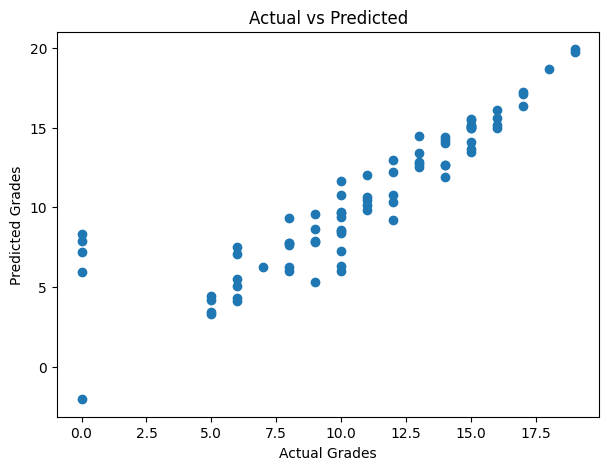

In [57]:
plt.figure(figsize=(7,5)) # Create a new figure for the plot with a specified size

plt.scatter( # Create a scatter plot
    y_test, # Actual grades on the x-axis
    y_pred # Predicted grades on the y-axis
)

plt.xlabel("Actual Grades") # Set the label for the x-axis

plt.ylabel("Predicted Grades") # Set the label for the y-axis

plt.title("Actual vs Predicted") # Set the title of the plot

plt.show() # Display the generated scatter plot

**Residual Plot**

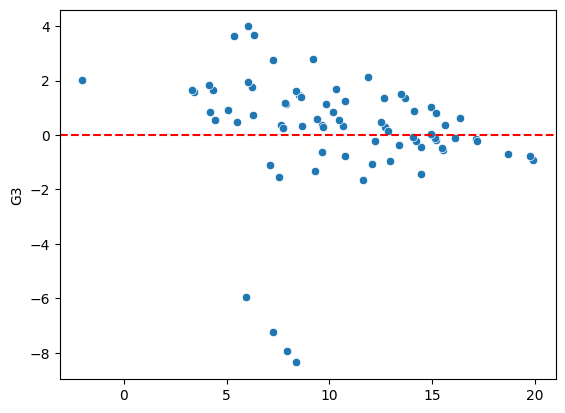

In [58]:
residuals = y_test - y_pred # Calculate the residuals (differences between actual and predicted values)

sns.scatterplot( # Create a scatter plot for residuals
    x=y_pred, # Predicted values on the x-axis
    y=residuals # Residuals on the y-axis
)

plt.axhline( # Add a horizontal line to the plot
    y=0, # Position the line at y=0
    color="red", # Set the color of the line to red
    linestyle="--" # Set the linestyle to dashed
)

plt.show() # Display the generated residual plot

In [59]:
#predict new student

new_student = [[ # Define a new student's data as a list of lists (required format for prediction)
    4,   # studytime: value for study time
    0,   # failures: value for past failures
    2,   # absences: value for absences
    14,  # G1: value for first period grade
    15   # G2: value for second period grade
]]

prediction = model.predict(new_student) # Use the trained model to predict the final grade for the new student

print(prediction) # Print the predicted final grade

[14.88897198]


**Save Model**

In [60]:
import joblib # Import the joblib library for saving and loading Python objects efficiently

joblib.dump( # Save the trained model to a file
    model, # The model object to be saved
    "student_grade_model.pkl" # The filename for the saved model ('.pkl' is a common extension for pickled objects)
)

['student_grade_model.pkl']